# Evaluation

This is the sixth and final notebook in the Elo7 Data Science Challenge project (full problem
statement: [`../docs/elo7-ds-challenge-en.md`](../docs/elo7-ds-challenge-en.md); notebooks 01-05
build the EDA, product classifier, intent classifier, recommender, and integrated system this
notebook evaluates together).

## The task

The spec's evaluation section asks for metrics for the product classifier and intent system,
justified rather than optimized for. This project's own scope is broader: five systems were
built across notebooks 02-05, and each one already did real evaluation work as it went, macro-F1
justified against class imbalance, confusion matrices, dummy baselines, hit-rate and recall
against historical clicks, an explicit tradeoff named and not hidden. Repeating all of that here
would pad this notebook without adding anything.

So this notebook does two things, kept clearly separate:

1. **Consolidate**, briefly, what earlier notebooks already established and justified, with a
   pointer back to the notebook that did the original work rather than a re-run.
2. **Fill three genuine gaps** that nothing has covered yet: clustering validity for the intent
   split (evaluated so far only as a downstream classification problem), a quantified diversity
   metric for the recommender (notebook 04 showed the tradeoff on one example query, never
   measured it), and cross-system validation, checking notebook 05's query-category classifier
   against real historical search behavior rather than only held-out product labels.

## Questions this notebook answers

1. **Classification**: what's the justified headline metric, and what do the actual
   misclassified products look like?
2. **Intent and clustering**: is the `specific`/`exploratory` split, evaluated as a clustering
   problem in its own right, actually well-separated?
3. **Recommendation and diversity**: how much diversity does the intent-aware hybrid actually
   buy, quantified rather than shown on one example?
4. **Cross-system validation**: does the query-category classifier predict what real searchers
   were actually looking for, and does that depend on the query's intent?
5. **What's next**: what would extend this project furthest, given everything found along the
   way?

## 1. Setup

In [2]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

from src.data.load import load_processed_dataset
from src.data.preprocess import deduplicate_products
from src.evaluation.metrics import category_diversity, evaluate_recommender
from src.features.text import joined_tokens
from src.models.classifier import NUMERIC_FEATURES, TEXT_FEATURE, build_pipeline
from src.models.intent import MIN_CLICKS_FOR_DISCOVERY, TOP_SHARE_THRESHOLD, category_top_share
from src.models.recommender import build_catalog, recommend_content, recommend_hybrid

%matplotlib inline

PRIMARY = "#2a78d6"  # Blue, the default single hue for magnitude comparisons.
SECONDARY = "#eb6834"  # Orange, the second series whenever a chart compares exactly two things.

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42

df = load_processed_dataset("01_data.parquet")
products = deduplicate_products(df)
products[TEXT_FEATURE] = [
    joined_tokens(t, tg) for t, tg in zip(products["title"], products["concatenated_tags"])
]

classifier_pipeline = joblib.load("../models/02_product_classifier.joblib")
tfidf = classifier_pipeline.named_steps["preprocess"].named_transformers_["text"]
intent_pipeline = joblib.load("../models/03_intent_classifier.joblib")
query_category_pipeline = joblib.load("../models/05_query_category_classifier.joblib")

catalog = build_catalog(products, tfidf)
print(f"{len(products):,} products, {df['query'].nunique():,} distinct queries loaded")

29,778 products, 6,392 distinct queries loaded


## 2. Classification metrics (Part 2)

**Recap** (full detail: notebook 02): macro-F1, not accuracy, is the headline metric, because
`category` is imbalanced roughly 15:1 even at the product level, and accuracy alone would be
dominated by the majority class. The final pipeline (TF-IDF product text + four numeric
features, `LinearSVC`) reaches macro-F1 0.85 / accuracy 0.88 on held-out products, against a
numeric-only baseline of macro-F1 0.40. `Outros` and `Papel e Cia` are the two hardest
categories.

**New here**: notebook 02's confusion matrix showed *counts* of `Papel e Cia`/`Lembrancinhas`
confusion. What do the actual misclassified products look like?

In [3]:
train, test = train_test_split(
    products, test_size=0.25, stratify=products["category"], random_state=RANDOM_STATE
)
eval_pipeline = build_pipeline()
eval_pipeline.fit(train[[TEXT_FEATURE, *NUMERIC_FEATURES]], train["category"])
test = test.copy()
test["predicted_category"] = eval_pipeline.predict(test[[TEXT_FEATURE, *NUMERIC_FEATURES]])

papel_as_lembrancinhas = test[
    (test["category"] == "Papel e Cia") & (test["predicted_category"] == "Lembrancinhas")
]
lembrancinhas_as_papel = test[
    (test["category"] == "Lembrancinhas") & (test["predicted_category"] == "Papel e Cia")
]

print(f"Papel e Cia -> predicted Lembrancinhas: {len(papel_as_lembrancinhas)} products")
print(papel_as_lembrancinhas[["title", "category", "predicted_category"]].head(4).to_string(index=False))
print(f"\nLembrancinhas -> predicted Papel e Cia: {len(lembrancinhas_as_papel)} products")
print(lembrancinhas_as_papel[["title", "category", "predicted_category"]].head(4).to_string(index=False))

Papel e Cia -> predicted Lembrancinhas: 139 products
                       title    category predicted_category
     Cadernos Personalizados Papel e Cia      Lembrancinhas
Adesivo para Caixinha Barbie Papel e Cia      Lembrancinhas
          Caixa dia dos pais Papel e Cia      Lembrancinhas
       Lápis + Borracha LEGO Papel e Cia      Lembrancinhas

Lembrancinhas -> predicted Papel e Cia: 56 products
                        title      category predicted_category
Caixa para os Pais dos noivos Lembrancinhas        Papel e Cia
       Convite Digital Crisma Lembrancinhas        Papel e Cia
Etiquetas Personalizadas Água Lembrancinhas        Papel e Cia
       Topo de bolo Minecraft Lembrancinhas        Papel e Cia


"Caixa dia dos pais" (a paper gift box) labeled `Papel e Cia` but predicted `Lembrancinhas`, and
"Convite Digital Crisma" (a digital invitation) labeled `Lembrancinhas` but predicted
`Papel e Cia`: these read as genuine category-boundary products, not model failures. A paper
gift box and a party favor box are, reasonably, both things; an invitation is, reasonably, both
a paper good and a party keepsake. No amount of additional tuning would resolve ambiguity that's
present in the sellers' own category choices.

## 3. Intent metrics (Part 3) and clustering evaluation

**Recap** (full detail: notebook 03): the `specific`/`exploratory` split, defined via
`top_share` and validated at a 0.8 threshold against an independent `KMeans(k=2)` boundary
(97% label agreement), generalizes to unseen queries via a text-only classifier at macro-F1
~0.68, a real improvement over a ~0.42 dummy baseline but well below notebook 02's product
classifier, an honestly-stated ceiling, not a shortcoming glossed over.

**New here**: notebook 03 used `KMeans` only to *validate a threshold*. Scored as a clustering
problem in its own right, using `silhouette_score`, how good is the split?

In [4]:
clicks_per_query = df.groupby("query").size()
eligible = clicks_per_query[clicks_per_query >= MIN_CLICKS_FOR_DISCOVERY].index
sub = df[df["query"].isin(eligible)]
query_level = sub.groupby("query").agg(top_share=("category", category_top_share)).reset_index()

X = query_level[["top_share"]].to_numpy()
manual_labels = (query_level["top_share"] >= TOP_SHARE_THRESHOLD).astype(int).to_numpy()

silhouette_scores = {}
for k in (2, 3, 4, 5):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X)
    silhouette_scores[k] = silhouette_score(X, labels_k)

pd.Series(silhouette_scores, name="silhouette_score").rename_axis("k")

k
2    0.786858
3    0.792276
4    0.811974
5    0.822395
Name: silhouette_score, dtype: float64

0.79 at `k=2`, a real, respectable score: the two clusters are genuinely well-separated, not an
arbitrary split. But silhouette keeps *climbing* through `k=5` (0.82), which would naively
suggest more clusters are better. They're not, for this project's purposes: `top_share`'s
distribution has a dense spike exactly at 1.0 (notebook 03, §3), so additional clusters mostly
carve small, trivially-separated slices off that spike rather than finding new structure that
matters. Two classes remains the right choice for reasons that were always domain-driven
(matching the spec's own suggested framing, defensible label volume per class), not something a
metric that keeps improving with more clusters should override, the exact distinction the spec
draws between justifying a metric and chasing the best score.

## 4. Recommendation metrics (Part 5, recommender half)

**Recap** (full detail: notebook 04): against historical clicks, content-based recommendations
reach 86.0% hit-rate@10 / 0.417 recall@10, far above popularity (1.4% / 0.001) or random. The
intent-aware hybrid trades some of that recall away for `exploratory` queries specifically
(88.1% -> 76.6% hit-rate) in exchange for category diversity, a tradeoff named but never
measured on the diversity side.

**New here**: `src.evaluation.metrics.category_diversity`, applied to the same 500-query sample
notebook 04 evaluated on.

In [5]:
clicks_per_query_products = df.groupby("query").size()
eligible_queries = clicks_per_query_products[clicks_per_query_products >= 3].index
query_clicks_full = df[df["query"].isin(eligible_queries)].groupby("query")["product_id"].apply(set)

rng = np.random.default_rng(RANDOM_STATE)
sample_queries = rng.choice(query_clicks_full.index.to_numpy(), size=500, replace=False)
predicted_intent = {q: intent_pipeline.predict([joined_tokens(q)])[0] for q in sample_queries}

diversity_rows = []
for q in sample_queries:
    content_cats = recommend_content(q, catalog, k=10)["category"]
    hybrid_cats = recommend_hybrid(q, catalog, intent_pipeline, k=10)["category"]
    diversity_rows.append(
        {
            "query": q,
            "intent": predicted_intent[q],
            "content_n_distinct": category_diversity(content_cats)["n_distinct"],
            "content_entropy": category_diversity(content_cats)["entropy"],
            "hybrid_n_distinct": category_diversity(hybrid_cats)["n_distinct"],
            "hybrid_entropy": category_diversity(hybrid_cats)["entropy"],
        }
    )
diversity_df = pd.DataFrame(diversity_rows)

summary = pd.DataFrame(
    {
        "all queries": diversity_df[["content_n_distinct", "content_entropy", "hybrid_n_distinct", "hybrid_entropy"]].mean(),
        "exploratory queries only": diversity_df.loc[
            diversity_df["intent"] == "exploratory",
            ["content_n_distinct", "content_entropy", "hybrid_n_distinct", "hybrid_entropy"],
        ].mean(),
    }
)
summary

,all queries,exploratory queries only
content_n_distinct,1.982000,2.447761
content_entropy,0.624299,0.956876
hybrid_n_distinct,3.142000,5.333333
hybrid_entropy,1.199299,2.387224


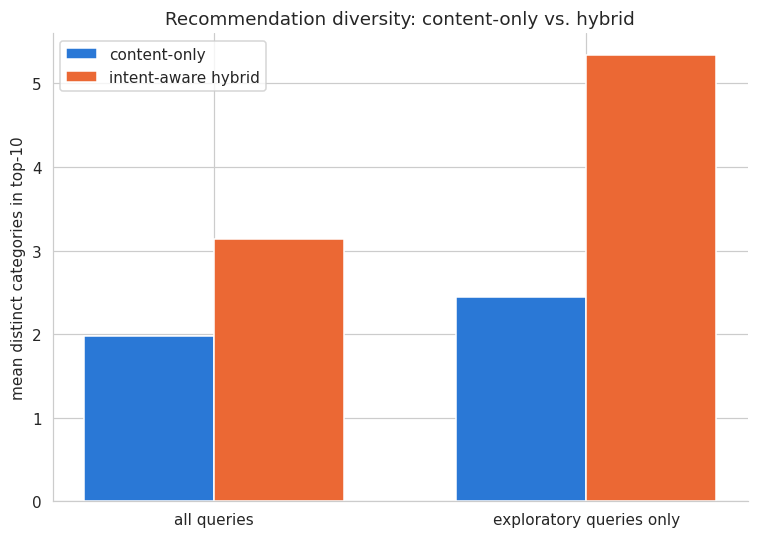

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
exploratory = diversity_df[diversity_df["intent"] == "exploratory"]
x = np.arange(2)
width = 0.35
ax.bar(x - width / 2, [summary.loc["content_n_distinct", "all queries"], summary.loc["content_n_distinct", "exploratory queries only"]], width, label="content-only", color=PRIMARY)
ax.bar(x + width / 2, [summary.loc["hybrid_n_distinct", "all queries"], summary.loc["hybrid_n_distinct", "exploratory queries only"]], width, label="intent-aware hybrid", color=SECONDARY)
ax.set_xticks(x)
ax.set_xticklabels(["all queries", "exploratory queries only"])
ax.set_ylabel("mean distinct categories in top-10")
ax.set_title("Recommendation diversity: content-only vs. hybrid")
ax.legend()
fig.tight_layout()
plt.show()

Averaged over all sampled queries, the hybrid nearly doubles category diversity (1.98 -> 3.14
distinct categories per top-10). Restricted to queries predicted `exploratory`, the gap is much
larger: 2.45 -> 5.33 distinct categories, entropy 0.96 -> 2.39 bits. That's the other half of
notebook 04's tradeoff, now measured rather than only shown on `"dia dos pais"`: a real,
substantial diversity gain, purchased at the recall cost notebook 04 already named.

## 5. Cross-system validation

Every evaluation so far has scored one system against its own kind of ground truth: products
against their own labels, queries against manufactured intent labels, recommendations against
historical clicks. Nothing has checked whether the query-category classifier (notebook 05),
validated so far only against held-out *product* labels, actually predicts what real
**searchers** were looking for. The dataset can answer this: for a query with enough click
history, compare the classifier's prediction against the **actual majority category of that
query's historical clicks**, using the same 500-query sample as §4 for direct comparability.

In [7]:
def majority_category(categories):
    return categories.value_counts().idxmax()

def top_share_of(categories):
    return categories.value_counts(normalize=True).iloc[0]

query_majority = sub.groupby("query")["category"].agg(
    majority_category=majority_category, top_share=top_share_of
)
sample = query_majority.loc[query_majority.index.intersection(sample_queries)].copy()
sample["predicted_category"] = query_category_pipeline.predict(
    [joined_tokens(q) for q in sample.index]
)
sample["match"] = sample["predicted_category"] == sample["majority_category"]

dummy_prediction = df["category"].value_counts().idxmax()
dummy_accuracy = (sample["majority_category"] == dummy_prediction).mean()

specific_mask = sample["top_share"] >= TOP_SHARE_THRESHOLD
results = pd.DataFrame(
    {
        "n": [len(sample), specific_mask.sum(), (~specific_mask).sum()],
        "accuracy": [
            sample["match"].mean(),
            sample.loc[specific_mask, "match"].mean(),
            sample.loc[~specific_mask, "match"].mean(),
        ],
    },
    index=["overall", "specific queries", "exploratory queries"],
)
print(f"dummy baseline (always predict {dummy_prediction!r}): {dummy_accuracy:.3f}")
results

dummy baseline (always predict 'Lembrancinhas'): 0.406


,n,accuracy
overall,500,0.864000
specific queries,363,0.955923
exploratory queries,137,0.620438


86.4% overall, far above the 40.6% dummy baseline, real evidence the query-category classifier
works on genuine search behavior, not just on held-out product labels. But split by predicted
intent, the story sharpens: 95.6% accuracy on `specific` queries, 62.0% on `exploratory` ones.
This makes sense by construction, not as a failure: an `exploratory` query's clicks genuinely
spread across several categories, so no single predicted category can match "the" majority well,
the same reason `top_share` is low for these queries in the first place. The intent classifier
isn't just a separate output sitting next to the category prediction, it's diagnostic
information about how much to trust it.

A few concrete disagreements, all from the `exploratory` bucket:

In [8]:
disagreements = sample[(~specific_mask) & (~sample["match"])].sort_values("top_share")
disagreements[["majority_category", "predicted_category", "top_share"]].head(6)

,majority_category,predicted_category,top_share
query,,,
festa super herois,Bebê,Lembrancinhas,0.250000
caixa de acetato,Lembrancinhas,Papel e Cia,0.333333
decoracao festa chuva,Bebê,Decoração,0.333333
festa stranger things,Lembrancinhas,Decoração,0.333333
frases para livro de ouro para formatura,Decoração,Lembrancinhas,0.333333
kit almofada,Bebê,Decoração,0.333333


`"festa super herois"` ("superhero party"), `"kit almofada"` ("pillow kit"), `"caixa de
acetato"` ("acetate box"): every one of these is a query that could plausibly lead to several
different kinds of products, exactly what a low `top_share` already says about them. The
classifier's single answer isn't wrong so much as the question ("what one category does this
belong to") is underspecified for these queries in the first place.

## 6. Error analysis

Pulling §2 and §5's concrete examples together: the errors across this project's systems cluster
into two kinds, and it's worth being precise about which is which.

**Genuine category-boundary ambiguity**, not fixable by more tuning: `Papel e Cia` vs.
`Lembrancinhas` products that are reasonably both things (§2); `exploratory` queries where no
single category is a good answer by construction (§5). More data or a different algorithm
wouldn't resolve these, because the ambiguity is in the underlying task, sellers and searchers
genuinely straddling categories, not in the model.

**A real, quantified limit, not an error exactly**: the intent generalization classifier's
macro-F1 ceiling (~0.68, notebook 03) reflects query text being a noisier proxy for click-scatter
behavior than product text is for product category. This isn't ambiguity in the same sense, it's
a harder underlying signal-recovery problem, honestly measured rather than hidden.

Nothing found here looks like a straightforward implementation bug or an obviously fixable
modeling choice; both categories of "error" are the dataset and task pushing back on a model
that's already doing about as well as the available signal allows.

## 7. Future work

Concrete extensions this project's own findings point to, not a generic wishlist:

- **Approximate nearest-neighbor search for the recommender.** Brute-force cosine similarity is
  fine at this project's ~30,000-product catalog (milliseconds per query, notebook 04), but the
  spec's own framing of Elo7's real catalog (~6 million products) would need an ANN index
  (e.g. HNSW) to stay fast.
- **A richer intent axis.** Price dispersion was considered and deliberately excluded from the
  primary intent classes (notebook 03) for label-volume reasons; with more labeled data, a
  combined specificity x price-tier framing could be revisited.
- **Real online evaluation.** The historical-click hit-rate/recall metric (notebook 04) can only
  reward recommendations that match Elo7's own past search ranking; it structurally cannot
  validate a genuinely better, more diverse recommendation the old ranking never surfaced. Only
  live traffic (an A/B test) could close that gap.
- **Confidence-aware category prediction for `exploratory` queries.** §5 shows a single
  predicted category is a poor fit specifically for `exploratory` queries. Rather than forcing
  one answer, the integrated system could return the top few candidate categories, or lean more
  heavily on the recommender's own category spread, when intent is `exploratory`.

## 8. Key findings & handoff

**Across all five systems:**

- Product classification (02): macro-F1 0.85, product text alone accounts for nearly all of it.
- Intent modeling (03): a validated, two-class behavioral split, generalizing to unseen queries
  at macro-F1 ~0.68, an honestly-stated ceiling.
- Recommendation (04): content similarity clears popularity by a wide margin; intent-aware
  diversification trades a real, named amount of historical-click recall for a real, now
  measured amount of category diversity (§4).
- Integration (05): the query -> category gap closes at a small (0.006 macro-F1), explained cost
  using a text-only classifier rather than fabricated numeric inputs.
- Cross-system validation (05's classifier against real search behavior, §5): 86.4% overall,
  95.6% on `specific` queries, 62.0% on `exploratory` ones, the clearest evidence in this project
  that the intent signal and the category signal are entangled in a way worth designing around,
  not two independent outputs bolted together.

**The project's central question**, whether user intent can be inferred from a search query
alone: yes, to a real, measured, and honestly-bounded degree. Category is recoverable from query
text with a small, quantified cost relative to having a product's full description (§5); a
behavioral notion of intent (specific vs. exploratory) is recoverable from query text alone at a
meaningfully lower but still genuinely useful ceiling (notebook 03, §3 here); and knowing which
kind of query it is materially changes both how reliable the category prediction is (§5) and how
the recommender should behave (§4).

This is the last notebook in the sequence; no further notebook to hand off to.

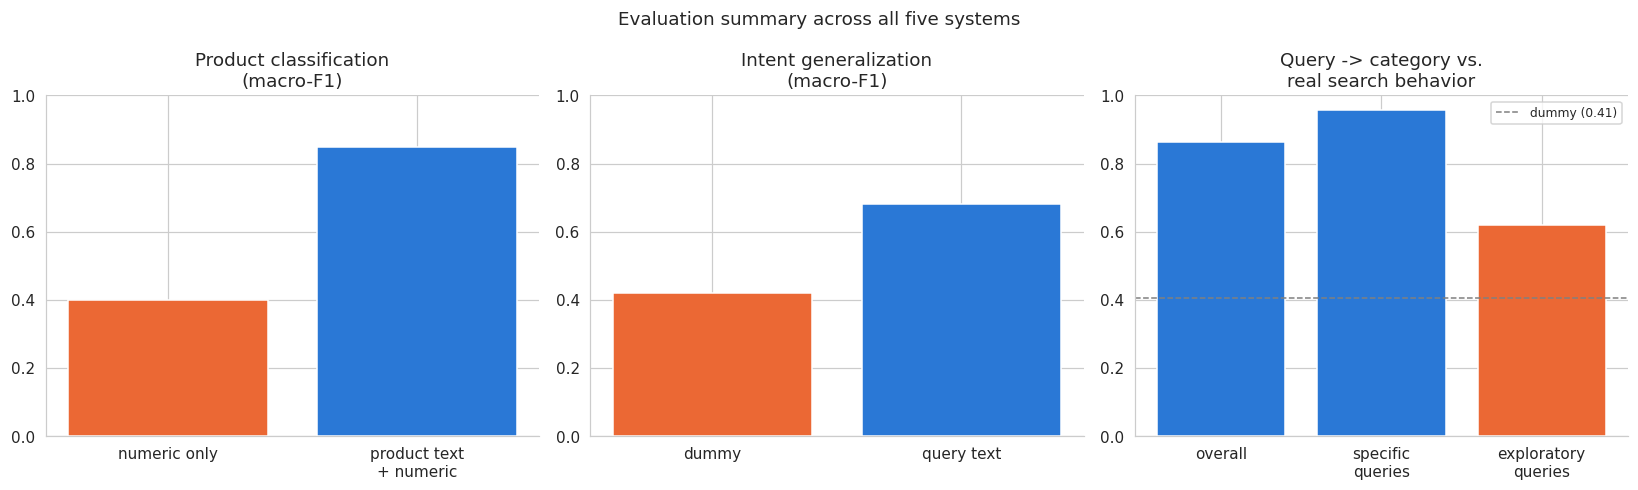

saved ../reports/06_evaluation_summary.png


In [9]:
from pathlib import Path

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

axs[0].bar(["numeric only", "product text\n+ numeric"], [0.40, 0.85], color=[SECONDARY, PRIMARY])
axs[0].set_title("Product classification\n(macro-F1)")
axs[0].set_ylim(0, 1)

axs[1].bar(["dummy", "query text"], [0.42, 0.68], color=[SECONDARY, PRIMARY])
axs[1].set_title("Intent generalization\n(macro-F1)")
axs[1].set_ylim(0, 1)

axs[2].bar(
    ["overall", "specific\nqueries", "exploratory\nqueries"],
    [results.loc["overall", "accuracy"], results.loc["specific queries", "accuracy"], results.loc["exploratory queries", "accuracy"]],
    color=[PRIMARY, PRIMARY, SECONDARY],
)
axs[2].axhline(dummy_accuracy, color="grey", linestyle="--", linewidth=1, label=f"dummy ({dummy_accuracy:.2f})")
axs[2].set_title("Query -> category vs.\nreal search behavior")
axs[2].set_ylim(0, 1)
axs[2].legend(fontsize=8)

fig.suptitle("Evaluation summary across all five systems")
fig.tight_layout()

reports_dir = Path("../reports")
reports_dir.mkdir(exist_ok=True)
fig.savefig(reports_dir / "06_evaluation_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("saved ../reports/06_evaluation_summary.png")